# EEG Motor Imagery: CBraMod vs EEGSimpleConv

End-to-end reproduction of both models on the SHU-MI dataset.

**Data split (subject-level, no leakage)**
- Train: subjects 1–15  
- Val:   subjects 16–20  
- Test:  subjects 21–25

**Task:** binary classification — left (0) vs right (1) motor imagery  
**Metrics:** balanced accuracy, ROC-AUC, PR-AUC

In [ ]:
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn

## 1 · Configuration

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────
ROOT         = Path('.')
MAT_DIR      = ROOT / 'data/shu-dataset/mat_files/mat'
LMDB_DIR     = ROOT / 'data/shu-dataset/processed_lmdb'
WEIGHTS_DIR  = ROOT / 'pretrained_weights'
WEIGHTS_FILE = WEIGHTS_DIR / 'pretrained_weights.pth'

# ── Subject split ─────────────────────────────────────────────────────────
TRAIN_SUBJECTS = list(range(1,  16))
VAL_SUBJECTS   = list(range(16, 21))
TEST_SUBJECTS  = list(range(21, 26))

# ── Shared hyper-parameters ───────────────────────────────────────────────
SEED        = 3407
EPOCHS      = 50
BATCH_SIZE  = 64
NUM_WORKERS = 4
CLIP_VALUE  = 1.0
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── CBraMod hyper-parameters ──────────────────────────────────────────────
N_CHANNELS    = 32
N_SEQUENCES   = 4
PATCH_SIZE    = 200
SCALE         = 100.0
FINETUNE_MODE = 'full'   # 'head_only' | 'full'
CLASSIFIER    = 'all_patch_reps'
LR_BACKBONE   = 1e-4
LR_HEAD       = 0.001 * (BATCH_SIZE / 256) ** 0.5   # ≈ 5e-4
WEIGHT_DECAY  = 5e-2
DROPOUT       = 0.1

# ── EEGSimpleConv hyper-parameters ────────────────────────────────────────
SFREQ       = 800
N_CLASSES   = 2
FM          = 64
N_CONVS     = 4
RESAMPLING  = 128
KERNEL_SIZE = 8
LR_EC       = 1e-3

print(f'Device : {DEVICE}')
print(f'Split  : train={len(TRAIN_SUBJECTS)} / val={len(VAL_SUBJECTS)} / test={len(TEST_SUBJECTS)} subjects')

Device : cuda
Split  : train=15 / val=5 / test=5 subjects


## 2 · Setup

### 2.1 Set Seed

In [22]:
from eeg_sigmanova.utils import set_seed

set_seed(SEED)
print(f'Seed {SEED} set.')

Seed 3407 set.


### 2.2 CBraMod Pretrained Weights

In [23]:
from huggingface_hub import hf_hub_download

WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
if not WEIGHTS_FILE.exists():
    print('Downloading pretrained weights from HuggingFace…')
    hf_hub_download(
        repo_id='weighting666/CBraMod',
        filename='pretrained_weights.pth',
        local_dir=str(WEIGHTS_DIR),
    )
else:
    print(f'Weights already present at {WEIGHTS_FILE}')

Weights already present at pretrained_weights/pretrained_weights.pth


### 2.1 · Preprocessing — Build LMDB

Reads raw `.mat` files and writes a shared LMDB used by both models.  
Each `.mat` file: `data (100, 32, n_pts)` @ 1000 Hz, `labels (100,)` {1=left, 2=right}.

Pipeline per trial: resample 1000 → 800 pts · reshape `(32, 4, 200)` · label−1 → {0,1}.

In [24]:
from eeg_sigmanova.data.preprocessing import build_lmdb

build_lmdb(
    mat_dir=MAT_DIR,
    lmdb_path=LMDB_DIR,
    split={'train': TRAIN_SUBJECTS, 'val': VAL_SUBJECTS, 'test': TEST_SUBJECTS},
)

Valid LMDB found at data/shu-dataset/processed_lmdb — skipping build.


## 3. Utils functions

In [ ]:
def plot_test_results(test_m, trainer, model_name, save_stem):
    cm = test_m['cm']
    tn, fp, fn, tp = cm.ravel()
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv         = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    f1          = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0
    fpr         = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    fig, (ax_cm, ax_bar) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        f'{model_name} Test Results \u2014 subjects 21\u201325  (best ckpt: epoch {trainer.best_epoch})',
        fontsize=12, fontweight='bold',
    )

    cm_T = cm.T
    cm_T_norm = cm_T.astype(float) / cm_T.sum(axis=1, keepdims=True)
    grid = np.full((3, 3), np.nan)
    grid[:2, :2] = cm_T_norm
    grid[0, 2] = npv;   grid[1, 2] = precision
    grid[2, 0] = specificity; grid[2, 1] = recall
    im = ax_cm.imshow(np.ma.array(grid, mask=np.isnan(grid)), cmap='Blues', vmin=0, vmax=1)
    ax_cm.set_xticks([0, 1, 2]); ax_cm.set_xticklabels(['Left', 'Right', ''])
    ax_cm.set_yticks([0, 1, 2]); ax_cm.set_yticklabels(['Left', 'Right', ''])
    ax_cm.set_xlabel('Ground-truth label', fontsize=11)
    ax_cm.set_ylabel('Predicted label',    fontsize=11)
    ax_cm.set_title('Confusion Matrix')
    thresh = 0.6
    for i in range(2):
        for j in range(2):
            c = 'white' if cm_T_norm[i, j] > thresh else 'black'
            ax_cm.text(j, i, f'{cm_T[i,j]:,}\n({cm_T_norm[i,j]:.1%})',
                       ha='center', va='center', fontsize=11, color=c)
    for col, row, lbl, val in [
        (2, 0, 'NPV',         npv),
        (2, 1, 'Precision',   precision),
        (0, 2, 'Specificity', specificity),
        (1, 2, 'Recall',      recall),
    ]:
        c = 'white' if val > thresh else 'black'
        ax_cm.text(col, row, f'{lbl}\n{val:.3f}',
                   ha='center', va='center', fontsize=10, fontweight='bold', color=c)
    ax_cm.plot([-0.5, 1.5], [1.5, 1.5], 'k-', lw=2)
    ax_cm.plot([1.5,  1.5], [-0.5, 1.5], 'k-', lw=2)
    plt.colorbar(im, ax=ax_cm, label='Row-normalised rate')

    metrics = {
        'ROC-AUC': test_m['roc_auc'], 'PR-AUC': test_m['pr_auc'],
        'Balanced Acc': test_m['acc'], 'F1': f1,
        'Precision': precision, 'Recall': recall,
        'Specificity': specificity, 'NPV': npv, 'FPR': fpr,
    }
    names, vals = list(metrics.keys()), list(metrics.values())
    colors = ['#2196F3' if v >= 0.65 else '#FF9800' if v >= 0.5 else '#F44336' for v in vals]
    bars = ax_bar.barh(names[::-1], vals[::-1], color=colors[::-1], height=0.6)
    ax_bar.set_xlim(0, 1.18); ax_bar.set_title('Metrics'); ax_bar.set_xlabel('Score')
    ax_bar.axvline(0.5, color='grey', linestyle=':', lw=0.8, label='Chance (0.5)')
    ax_bar.legend(fontsize=8)
    for bar, val in zip(bars, vals[::-1]):
        ax_bar.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(ROOT / f'{save_stem}_test_results.png', dpi=150)
    plt.show()


def plot_training_curves(trainer, model_name, loss_label, save_stem):
    epochs_range = range(1, len(trainer.history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs_range, trainer.history['train_loss'], label='Train')
    axes[0].plot(epochs_range, trainer.history['val_loss'],   label='Val')
    axes[0].set_title(f'{model_name} \u2014 Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel(loss_label)
    axes[0].axvline(trainer.best_epoch, color='red', linestyle='--',
                    label=f'Best (ep {trainer.best_epoch})')
    axes[0].legend()
    axes[1].plot(epochs_range, trainer.history['val_roc_auc'], label='ROC-AUC')
    axes[1].plot(epochs_range, trainer.history['val_pr_auc'],  label='PR-AUC')
    axes[1].plot(epochs_range, trainer.history['val_acc'],     label='Balanced Acc')
    axes[1].set_title(f'{model_name} \u2014 Validation Metrics')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
    axes[1].axvline(trainer.best_epoch, color='red', linestyle='--',
                    label=f'Best (ep {trainer.best_epoch})')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(ROOT / f'{save_stem}_training_curves.png', dpi=150)
    plt.show()


## 4 · CBraMod Finetuning

### 4.1 · Dataset & DataLoaders

In [ ]:
from eeg_sigmanova.data.dataset import make_patch_loaders

cb_loaders = make_patch_loaders(LMDB_DIR, BATCH_SIZE, NUM_WORKERS, device=DEVICE, scale=SCALE)

for split, dl in cb_loaders.items():
    print(f'{split:5s}: {len(dl.dataset):5d} trials — {len(dl)} batches')
x, y = next(iter(cb_loaders['train']))
print(f'\nBatch — x: {tuple(x.shape)},  y: {tuple(y.shape)}')

train:  7210 trials — 113 batches
val  :  2431 trials — 38 batches
test :  2347 trials — 37 batches

Batch — x: (64, 32, 4, 200),  y: (64,)


### 4.2 · Model

In [ ]:
from eeg_sigmanova.models.cbramod_classifier import CBraModBinaryClassifier

cb_model = CBraModBinaryClassifier(
    weights_path=WEIGHTS_FILE,
    classifier=CLASSIFIER,
    dropout=DROPOUT,
    device=DEVICE,
    n_channels=N_CHANNELS,
    n_patches=N_SEQUENCES,
).to(DEVICE)

for name, param in cb_model.named_parameters():
    if 'backbone' in name:
        param.requires_grad = (FINETUNE_MODE == 'full')

trainable = sum(p.numel() for p in cb_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in cb_model.parameters())
print(f'Fine-tune mode  : {FINETUNE_MODE}')
print(f'Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)')

Fine-tune mode  : full
Trainable params: 25,525,001 / 25,525,001  (100.0%)


### 4.3 · Optimiser & Scheduler

In [28]:
if FINETUNE_MODE == 'head_only':
    cb_param_groups = [{'params': [p for p in cb_model.parameters() if p.requires_grad], 'lr': LR_HEAD}]
else:
    cb_param_groups = [
        {'params': [p for n, p in cb_model.named_parameters() if 'backbone' in n], 'lr': LR_BACKBONE},
        {'params': [p for n, p in cb_model.named_parameters() if 'backbone' not in n], 'lr': LR_HEAD},
    ]

cb_optimizer  = torch.optim.AdamW(cb_param_groups, weight_decay=WEIGHT_DECAY)
cb_scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
    cb_optimizer, T_max=EPOCHS * len(cb_loaders['train']), eta_min=1e-6
)
cb_criterion  = nn.BCEWithLogitsLoss().to(DEVICE)
print(f'Head LR: {LR_HEAD:.5f}  |  backbone: {"frozen" if FINETUNE_MODE=="head_only" else LR_BACKBONE}')

Head LR: 0.00050  |  backbone: 0.0001


### 4.4 · Training

In [ ]:
import logging
logging.basicConfig(level=logging.INFO, format='%(message)s')

from eeg_sigmanova.training.trainer import Trainer

cbramod_trainer = Trainer(
    model=cb_model, optimizer=cb_optimizer, criterion=cb_criterion,
    device=DEVICE, scheduler=cb_scheduler,
    clip_value=CLIP_VALUE, scheduler_step='batch', use_sigmoid=True,
)
cbramod_trainer.fit(cb_loaders['train'], cb_loaders['val'], epochs=EPOCHS)

Epoch   1/50 | train 0.6993 | val 0.6704 | val acc 0.6412 | val ROC-AUC 0.7108 | val PR-AUC 0.7387 | lr 9.99e-05 | 0.1 min  <- best
Epoch   2/50 | train 0.6675 | val 0.6099 | val acc 0.6346 | val ROC-AUC 0.7210 | val PR-AUC 0.7314 | lr 9.96e-05 | 0.1 min  <- best
Epoch   3/50 | train 0.6227 | val 0.6074 | val acc 0.6436 | val ROC-AUC 0.7267 | val PR-AUC 0.7452 | lr 9.91e-05 | 0.1 min  <- best
Epoch   4/50 | train 0.5922 | val 0.6356 | val acc 0.6591 | val ROC-AUC 0.7257 | val PR-AUC 0.7324 | lr 9.84e-05 | 0.1 min
Epoch   5/50 | train 0.5341 | val 0.6767 | val acc 0.6594 | val ROC-AUC 0.7200 | val PR-AUC 0.7276 | lr 9.76e-05 | 0.1 min
Epoch   6/50 | train 0.4655 | val 0.7374 | val acc 0.6422 | val ROC-AUC 0.7182 | val PR-AUC 0.7256 | lr 9.65e-05 | 0.1 min
Epoch   7/50 | train 0.3790 | val 0.8270 | val acc 0.6282 | val ROC-AUC 0.6934 | val PR-AUC 0.7068 | lr 9.53e-05 | 0.1 min
Epoch   8/50 | train 0.2698 | val 0.9476 | val acc 0.6586 | val ROC-AUC 0.7270 | val PR-AUC 0.7310 | lr 9.39e-05

### 4.5 · Test Evaluation

In [ ]:
from eeg_sigmanova.training.evaluator import evaluate

cbramod_trainer.load_best()
cbramod_test_metrics = evaluate(cb_model, cb_loaders['test'], DEVICE)

print('=' * 50)
print('CBraMod TEST RESULTS  (subjects 21–25)')
print('=' * 50)
print(f"  Balanced Accuracy : {cbramod_test_metrics['acc']:.4f}")
print(f"  ROC-AUC           : {cbramod_test_metrics['roc_auc']:.4f}")
print(f"  PR-AUC            : {cbramod_test_metrics['pr_auc']:.4f}")

CBraMod TEST RESULTS  (subjects 21–25)
  Balanced Accuracy : 0.6033
  ROC-AUC           : 0.6586
  PR-AUC            : 0.6704


### 4.6 · Visualisation

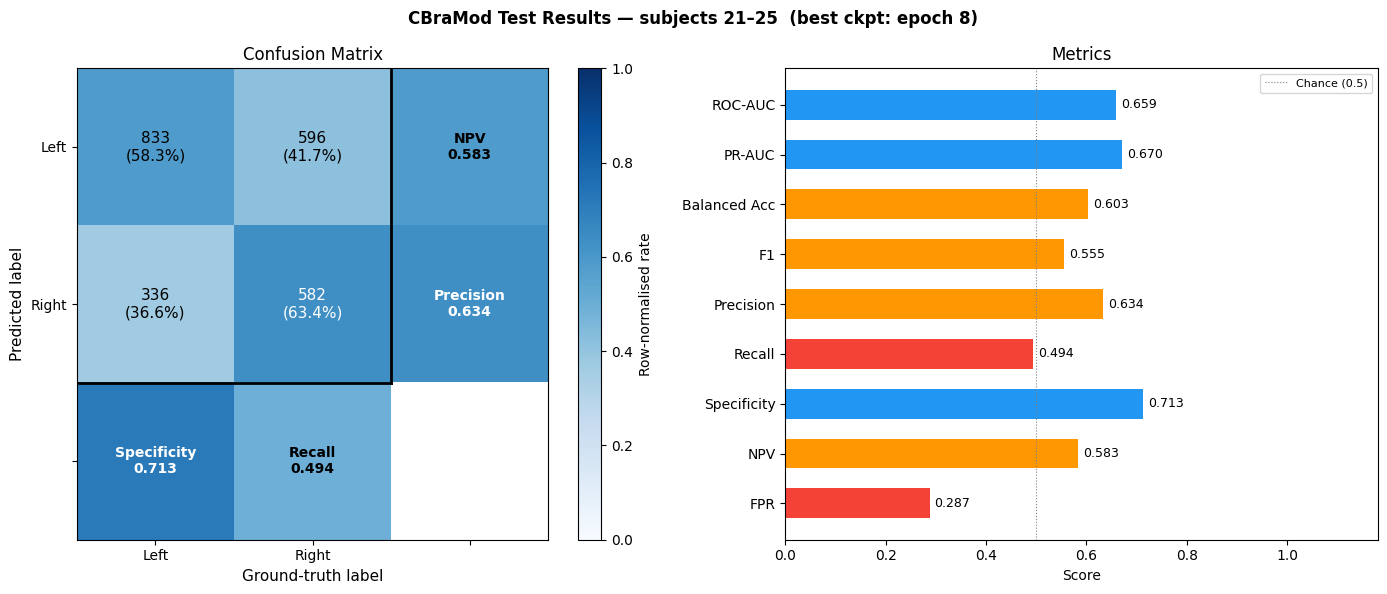

In [ ]:
plot_test_results(cbramod_test_metrics, cbramod_trainer, 'CBraMod', 'cbramod')

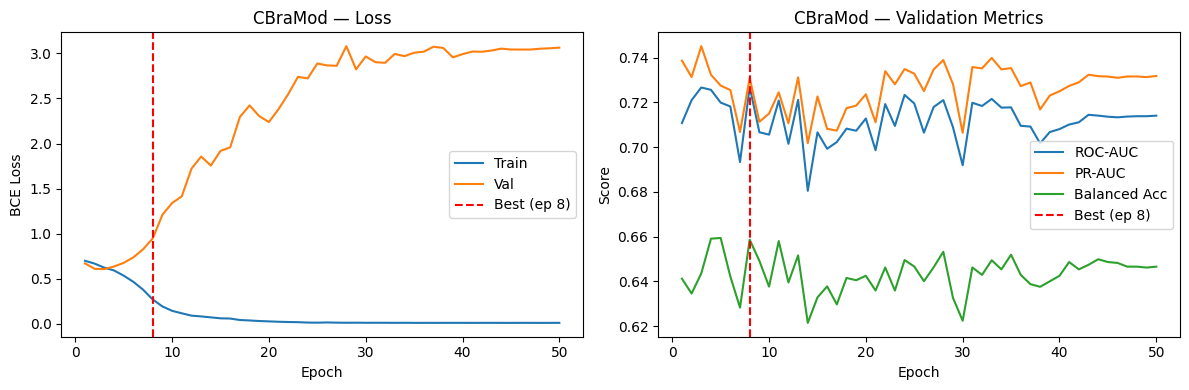

In [ ]:
plot_training_curves(cbramod_trainer, 'CBraMod', 'BCE Loss', 'cbramod')

## 5 · EEGSimpleConv Training

### 5.1 · Dataset & DataLoaders

Reshapes stored patches `(32, 4, 200)` → `(32, 800)` and applies per-channel z-score normalisation.

In [33]:
from eeg_sigmanova.data.dataset import make_raw_loaders

print('Computing normalisation statistics from training set...')
ec_loaders, mean_ch, std_ch = make_raw_loaders(
    LMDB_DIR, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    n_channels=N_CHANNELS, device=DEVICE,
)
print(f'Channel mean: [{mean_ch.min():.3f}, {mean_ch.max():.3f}]')
print(f'Channel std : [{std_ch.min():.3f}, {std_ch.max():.3f}]')
for split, dl in ec_loaders.items():
    print(f'{split:5s}: {len(dl.dataset):5d} trials — {len(dl)} batches')

Computing normalisation statistics from training set...
Channel mean: [-0.000, 0.000]
Channel std : [10.869, 1213.666]
train:  7210 trials — 113 batches
val  :  2431 trials — 38 batches
test :  2347 trials — 37 batches


### 5.2 · Model

In [ ]:
from eeg_sigmanova.models.eeg_simple_conv import EEGSimpleConv

ec_model = EEGSimpleConv(
    fm=FM, n_convs=N_CONVS, resampling=RESAMPLING, kernel_size=KERNEL_SIZE,
    n_channels=N_CHANNELS, n_classes=N_CLASSES, sfreq=SFREQ,
).to(DEVICE)

total = sum(p.numel() for p in ec_model.parameters())
print(f'Parameters: {total:,}')

Parameters: 853,792


### 5.3 · Optimiser & Scheduler

In [35]:
ec_optimizer = torch.optim.Adam(ec_model.parameters(), lr=LR_EC)
ec_scheduler = torch.optim.lr_scheduler.StepLR(
    ec_optimizer, step_size=(4 * EPOCHS) // 5, gamma=0.1
)
ec_criterion = nn.CrossEntropyLoss().to(DEVICE)
print(f'LR: {LR_EC}  |  LR step at epoch {(4 * EPOCHS) // 5} (×0.1)')

LR: 0.001  |  LR step at epoch 40 (×0.1)


### 5.4 · Training

In [ ]:
eeg_simple_conv_trainer = Trainer(
    model=ec_model, optimizer=ec_optimizer, criterion=ec_criterion,
    device=DEVICE, scheduler=ec_scheduler,
    clip_value=CLIP_VALUE, scheduler_step='epoch', use_sigmoid=False,
)
eeg_simple_conv_trainer.fit(ec_loaders['train'], ec_loaders['val'], epochs=EPOCHS)

Epoch   1/50 | train 0.7020 | val 0.6684 | val acc 0.6114 | val ROC-AUC 0.6368 | val PR-AUC 0.6653 | lr 1.00e-03 | 0.0 min  <- best
Epoch   2/50 | train 0.6892 | val 0.6331 | val acc 0.6463 | val ROC-AUC 0.6827 | val PR-AUC 0.7082 | lr 1.00e-03 | 0.0 min  <- best
Epoch   3/50 | train 0.6774 | val 0.6283 | val acc 0.6503 | val ROC-AUC 0.6894 | val PR-AUC 0.7076 | lr 1.00e-03 | 0.0 min  <- best
Epoch   4/50 | train 0.6692 | val 0.6358 | val acc 0.6360 | val ROC-AUC 0.6701 | val PR-AUC 0.7139 | lr 1.00e-03 | 0.0 min
Epoch   5/50 | train 0.6672 | val 0.6373 | val acc 0.6385 | val ROC-AUC 0.6809 | val PR-AUC 0.7013 | lr 1.00e-03 | 0.0 min
Epoch   6/50 | train 0.6605 | val 0.6149 | val acc 0.6475 | val ROC-AUC 0.7100 | val PR-AUC 0.7324 | lr 1.00e-03 | 0.0 min  <- best
Epoch   7/50 | train 0.6486 | val 0.6273 | val acc 0.6564 | val ROC-AUC 0.7205 | val PR-AUC 0.7233 | lr 1.00e-03 | 0.0 min  <- best
Epoch   8/50 | train 0.6446 | val 0.6054 | val acc 0.6634 | val ROC-AUC 0.7314 | val PR-AUC 0.

### 5.5 · Test Evaluation

In [ ]:
eeg_simple_conv_trainer.load_best()
eeg_simple_conv_test_metrics = evaluate(ec_model, ec_loaders['test'], DEVICE, use_sigmoid=False)

print('=' * 50)
print('EEGSimpleConv TEST RESULTS  (subjects 21–25)')
print('=' * 50)
print(f"  Balanced Accuracy : {eeg_simple_conv_test_metrics['acc']:.4f}")
print(f"  ROC-AUC           : {eeg_simple_conv_test_metrics['roc_auc']:.4f}")
print(f"  PR-AUC            : {eeg_simple_conv_test_metrics['pr_auc']:.4f}")

EEGSimpleConv TEST RESULTS  (subjects 21–25)
  Balanced Accuracy : 0.6404
  ROC-AUC           : 0.7039
  PR-AUC            : 0.6985


### 5.6 · Visualisation

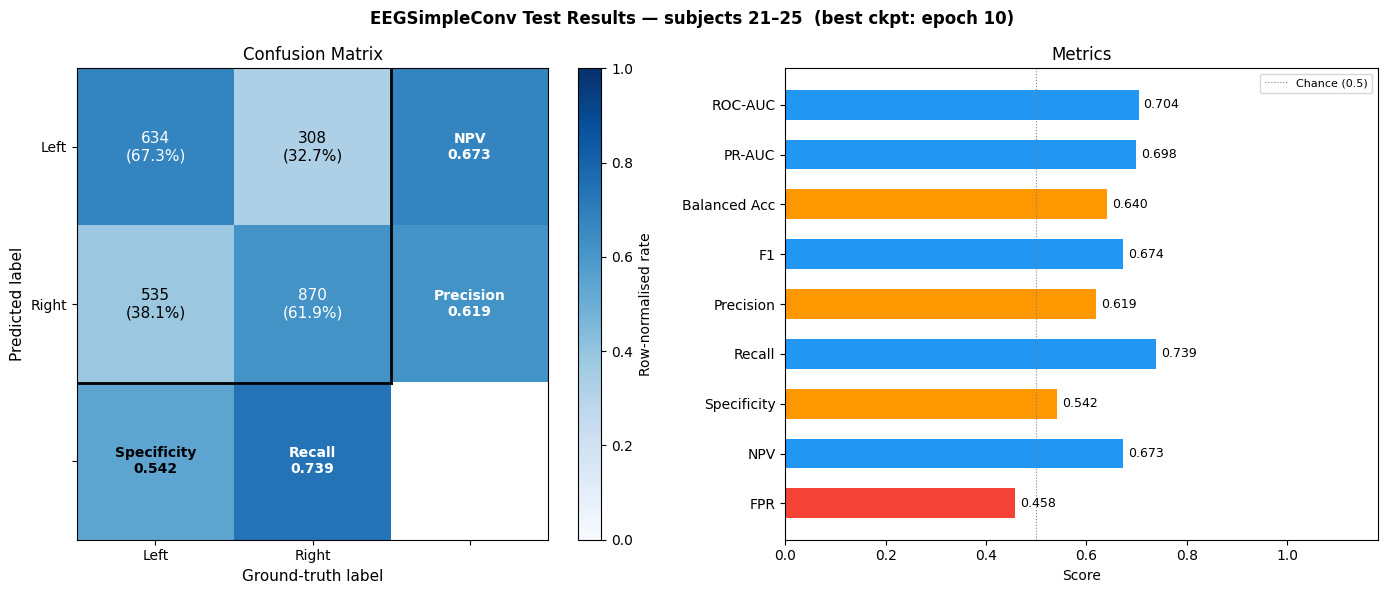

In [ ]:
plot_test_results(eeg_simple_conv_test_metrics, eeg_simple_conv_trainer, 'EEGSimpleConv', 'eeg_simple_conv')

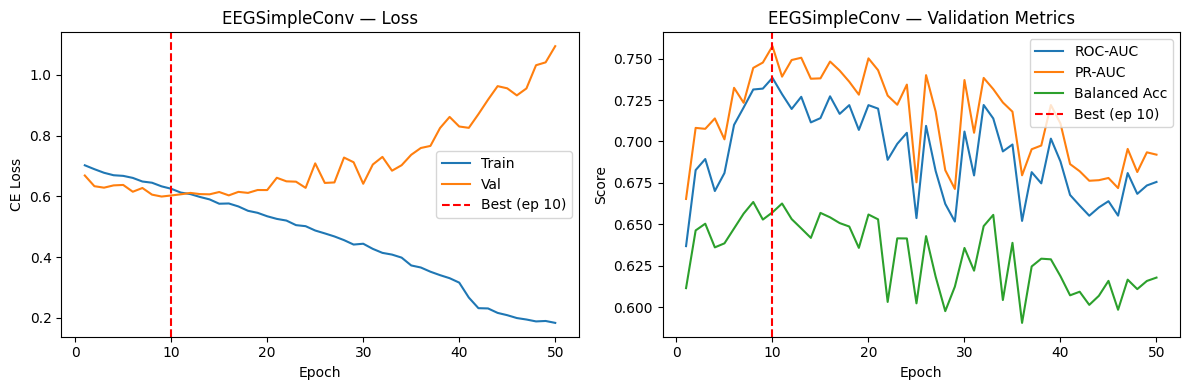

In [ ]:
plot_training_curves(eeg_simple_conv_trainer, 'EEGSimpleConv', 'CE Loss', 'eeg_simple_conv')

## 6 · Comparison

                       Params Pretrained  Balanced Acc  ROC-AUC  PR-AUC  Best epoch
Model                                                                              
CBraMod (full)         25.5 M  Yes (MAE)        0.6033   0.6586  0.6704           8
EEGSimpleConv (fm=64)   854 K         No        0.6404   0.7039  0.6985          10


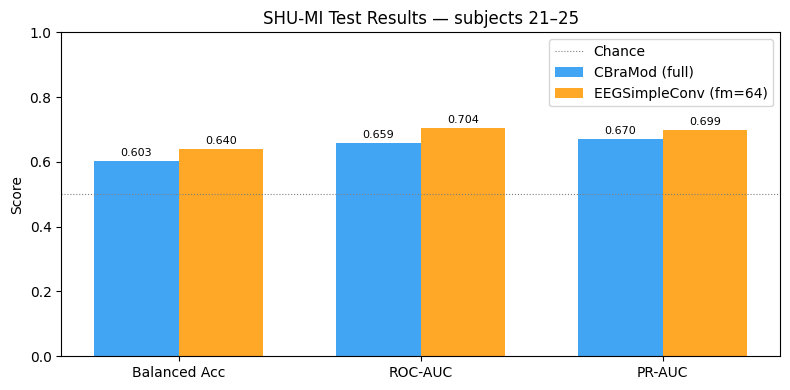

In [ ]:
import pandas as pd

cb_params = sum(p.numel() for p in cb_model.parameters())
ec_params = sum(p.numel() for p in ec_model.parameters())

results = [
    {
        'Model':         f'CBraMod ({FINETUNE_MODE})',
        'Params':        f'{cb_params/1e6:.1f} M',
        'Pretrained':    'Yes (MAE)',
        'Balanced Acc':  round(cbramod_test_metrics['acc'],     4),
        'ROC-AUC':       round(cbramod_test_metrics['roc_auc'], 4),
        'PR-AUC':        round(cbramod_test_metrics['pr_auc'],  4),
        'Best epoch':    cbramod_trainer.best_epoch,
    },
    {
        'Model':         f'EEGSimpleConv (fm={FM})',
        'Params':        f'{ec_params/1e3:.0f} K',
        'Pretrained':    'No',
        'Balanced Acc':  round(eeg_simple_conv_test_metrics['acc'],     4),
        'ROC-AUC':       round(eeg_simple_conv_test_metrics['roc_auc'], 4),
        'PR-AUC':        round(eeg_simple_conv_test_metrics['pr_auc'],  4),
        'Best epoch':    eeg_simple_conv_trainer.best_epoch,
    },
]
df = pd.DataFrame(results).set_index('Model')
print(df.to_string())

metrics_to_plot = ['Balanced Acc', 'ROC-AUC', 'PR-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, [results[0][m] for m in metrics_to_plot], width,
       label=results[0]['Model'], color='#2196F3', alpha=0.85)
ax.bar(x + width/2, [results[1][m] for m in metrics_to_plot], width,
       label=results[1]['Model'], color='#FF9800', alpha=0.85)
ax.axhline(0.5, color='grey', linestyle=':', lw=0.8, label='Chance')
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1); ax.set_ylabel('Score')
ax.set_title('SHU-MI Test Results — subjects 21–25')
ax.legend()
for i, m in enumerate(metrics_to_plot):
    for j, (res, off) in enumerate([(results[0], -width/2), (results[1], width/2)]):
        ax.text(i + off, res[m] + 0.01, f"{res[m]:.3f}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / 'shu_mi_comparison.png', dpi=150)
plt.show()

## 7 · Save Checkpoints

In [ ]:
cb_ckpt = ROOT / f'shu_mi_epoch{cbramod_trainer.best_epoch}_roc{cbramod_trainer.best_roc_auc:.4f}.pth'
ec_ckpt = ROOT / f'eeg_simple_conv_epoch{eeg_simple_conv_trainer.best_epoch}_roc{eeg_simple_conv_trainer.best_roc_auc:.4f}.pth'
torch.save(cb_model.state_dict(), cb_ckpt)
torch.save(ec_model.state_dict(), ec_ckpt)
print(f'CBraMod checkpoint : {cb_ckpt}')
print(f'EEGSimpleConv ckpt : {ec_ckpt}')

CBraMod checkpoint : shu_mi_epoch8_roc0.7270.pth
EEGSimpleConv ckpt : eegconv_epoch10_roc0.7384.pth


## 8. Models Comparison

| | **CBraMod** | **EEGSimpleConv** |
|---|---|---|
| Family | Transformer | 1-D CNN |
| Parameters | ~25.5 M | 853,792 |
| Input format | `(B, C, S, P)` — patched signal | `(B, C, T)` — raw signal |
| Pretraining | Self-supervision using Patch Masking on large EEG corpus | None (random init) |
| Temporal modelling | Spectral FFT per patch → Transformer | Hierarchical conv + MaxPool (×2 per block) |
| Spatial modelling | Criss-cross attention (channel ↔ sequence) | Single mixing Conv1d at the stem |
| Resampling | Done once in preprocessing | `torchaudio.Resample` inside the model |
| Normalization | Fixed scaling (/100) | Per-channel z-score from training set |
| Inductive bias | Global attention over all patches | Local receptive field growing with depth |

---

### Architecture deep-dive

**CBraMod** is built around three ideas:

1. **Patch embedding** splits each channel's signal into fixed-size temporal patches,  
   applies a spatial convolution across channels, and enriches each patch with a  
   spectral (FFT-based) feature — giving it both time-domain and frequency-domain  
   awareness.

2. **Criss-cross attention** alternates between attending across *channels* (spatial)  
   and attending across *patches* (temporal) in interleaved layers. This is cheaper  
   than full spatiotemporal attention while still capturing long-range dependencies 
   in both dimensions.

3. **MAE pretraining** masks random patches and trains the encoder to reconstruct  
   them.

**EEGSimpleConv** makes the opposite design choices:

1. A single `Conv1d` stem mixes all channels into `fm` feature maps — the only  
   spatial integration step in the whole network.

2. A stack of `n_convs` identical blocks each applies two `Conv1d` + BN + ReLU  
   with a `MaxPool1d(2)` in between. Feature maps grow by ×√2 per block, so depth  
   increases representational capacity without an explosion in parameters.

3. Global average pooling collapses the time dimension, and a single linear layer  
   produces the class logits. The entire pipeline is ≤10 layers deep.

---

### When to prefer CBraMod

- **Cross-subject generalisation with small labelled datasets.** Pretrained weights  
  encode generic EEG structure; fine-tuning the head alone can outperform a CNN  
  trained from scratch when labels are scarce.
- **You can continue pretraining.** If you have access to large unlabelled EEG  
  recordings (clinical, resting-state), further Masked Patching reconstruction pretraining 
  before fine-tuning amplifies the transfer advantage.
- **Multi-dataset / multi-task benchmarking.** A single backbone can be shared  
  across tasks (MI, sleep staging, emotion) with task-specific heads.

### When to prefer EEGSimpleConv

- **Within-subject settings.** When train and test come from the same person,  
  pretraining offers no distribution-shift advantage 
- **Small dataset.** When you have small dataset since Transformers requires a lot of data.
  Smaller models using CNN can outperform Transformers.
- **Fast iteration / prototyping.** Training is faster and the model fits in a  
  fraction of GPU memory — useful for hyperparameter sweeps or ablation studies.
- **Resource-constrained deployment.** ~800 K parameters can run in real time on  
  a CPU or microcontroller; CBraMod at 25 M parameters cannot.
- **Interpretability.** First-layer `Conv1d` filters have a direct frequency  
  interpretation (they are essentially learned FIR filters), and intermediate  
  feature maps can be visualised easily.

---

### Takeaway from this experiment

- CBraMod overfits heavily in *full fine-tuning* mode (train loss → 0.01,  
  val loss → 3.0 by epoch 50) because 25 M parameters are far too many for  
  7 200 labelled trials. Its advantage is only visible when the backbone is frozen  
  (`FINETUNE_MODE = 'head_only'`).
- EEGSimpleConv is smaller and trains from scratch, so it has far less  capacity to memorise subject-specific artefacts.